In [24]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
import sys
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils
import matplotlib.pyplot as plt

In [9]:
%autoreload 2

__Get all saccade dataframes__

In [44]:
path = "C://Data//Imaging//"
genotypes = {
    'Casper':
        [r"C:\Data\Imaging\260325_frmd7\fish9",
        r"C:\Data\Imaging\260325_frmd7\fish11",
        r"C:\Data\Imaging\260325_frmd7\fish12",
        r"C:\Data\Imaging\260325_frmd7\fish13",
        r"C:\Data\Imaging\260325_frmd7\fish16"],
    'frmd7KO':
        [r"C:\Data\Imaging\260325_frmd7\fish17",
        r"C:\Data\Imaging\260325_frmd7\fish7",
        r"C:\Data\Imaging\260325_frmd7\fish8",
        r"C:\Data\Imaging\260325_frmd7\fish10",
        r"C:\Data\Imaging\260325_frmd7\fish14"]}
all_dfs = []
for geno in genotypes.keys():
    for fish in genotypes[geno]:
        saccade_df = pd.read_csv( fish + '//eye//proofread_eye_saccade_df.csv', index_col=0)
        saccade_df.loc[:, "fish_id"] = fish
        saccade_df.loc[:, "Genotype"] = geno
        all_dfs.append(saccade_df)
all_dfs = pd.concat(all_dfs).reset_index(drop = True)

all_dfs

,cont_tuples_eyeindex,cont_tuples_realtime_s,e0_change,e1_change,eye_stimuli,eye_realstimuli,eye_fromstart_s,e_conv_change,e_conj_change,fish_id,Genotype
0,"(1197, 1262)","(13.73526, 14.579002)",-2.660917,-11.574188,right,right,13.735260,-8.913270,-14.235105,C:\Data\Imaging\260325_frmd7\fish9,Casper
1,"(1277, 1287)","(14.779467, 14.913111)",0.188310,1.245265,right,right,14.779467,1.056955,1.433576,C:\Data\Imaging\260325_frmd7\fish9,Casper
2,"(1571, 1634)","(18.443666, 19.254497)",-2.510868,-7.384271,right,right,18.443666,-4.873404,-9.895139,C:\Data\Imaging\260325_frmd7\fish9,Casper
3,"(1794, 1955)","(21.386792, 23.53006)",-10.868613,-15.241133,right,right,21.386792,-4.372520,-26.109747,C:\Data\Imaging\260325_frmd7\fish9,Casper
4,"(4179, 4242)","(52.190395, 53.0112)",8.644099,3.050517,left,left,12.162466,-5.593581,11.694616,C:\Data\Imaging\260325_frmd7\fish9,Casper
...,...,...,...,...,...,...,...,...,...,...,...
984,"(104131, 104208)","(1178.009431, 1178.865142)",-8.585731,-2.674128,dot_l,dot_l,16.519808,5.911603,-11.259860,C:\Data\Imaging\260325_frmd7\fish14,frmd7KO
985,"(108442, 108523)","(1225.881378, 1226.780972)",-4.152007,-4.658541,pause,stationary,24.323936,-0.506533,-8.810548,C:\Data\Imaging\260325_frmd7\fish14,frmd7KO
986,"(114816, 114941)","(1296.662045, 1298.049334)",9.941162,-4.870130,pause,stationary,95.104603,-14.811292,5.071032,C:\Data\Imaging\260325_frmd7\fish14,frmd7KO
987,"(127247, 127382)","(1434.711774, 1436.210766)",4.325956,-5.996992,pause,stationary,233.154332,-10.322948,-1.671036,C:\Data\Imaging\260325_frmd7\fish14,frmd7KO


In [38]:
all_dfs = all_dfs.drop(['cont_tuples_realtime_s', 'cont_tuples_eyeindex', 'eye_stimuli'], axis = 1).groupby(['eye_realstimuli', 'fish_id', 'Genotype']).mean().reset_index()

all_dfs

,eye_realstimuli,fish_id,Genotype,e0_change,e1_change,eye_fromstart_s,e_conv_change,e_conj_change
0,dot_l,C:\Data\Imaging\260325_frmd7\fish10,frmd7KO,3.277972,1.165011,16.175731,-2.112961,4.442983
1,dot_l,C:\Data\Imaging\260325_frmd7\fish13,Casper,4.172613,-1.862534,17.019475,-6.035147,2.310079
2,dot_l,C:\Data\Imaging\260325_frmd7\fish14,frmd7KO,5.582240,1.475326,16.585554,-4.106914,7.057566
3,dot_l,C:\Data\Imaging\260325_frmd7\fish16,Casper,13.826061,11.353784,17.290750,-2.472278,25.179845
4,dot_l,C:\Data\Imaging\260325_frmd7\fish17,frmd7KO,-0.598622,-4.328743,15.681553,-3.730121,-4.927366
5,dot_l,C:\Data\Imaging\260325_frmd7\fish7,frmd7KO,1.008554,-9.842988,16.515323,-10.851542,-8.834434
6,dot_l,C:\Data\Imaging\260325_frmd7\fish8,frmd7KO,6.926586,1.201242,15.519486,-5.725344,8.127827
7,dot_l,C:\Data\Imaging\260325_frmd7\fish9,Casper,9.879526,-2.485737,18.624182,-12.365263,7.393789
8,dot_r,C:\Data\Imaging\260325_frmd7\fish10,frmd7KO,2.251572,-0.846864,17.073440,-3.098436,1.404707
9,dot_r,C:\Data\Imaging\260325_frmd7\fish11,Casper,7.783342,0.775989,16.250234,-7.007353,8.559330


In [16]:
stimorder = ['stationary', 'left', 'right']

In [17]:
utils.stim_colors['stationary']

(0.8, 0.8, 0.8, 1)

__EXAMPLE CODE: PLOT THE MEAN SACCADE ANGLE OF ALL FISH__

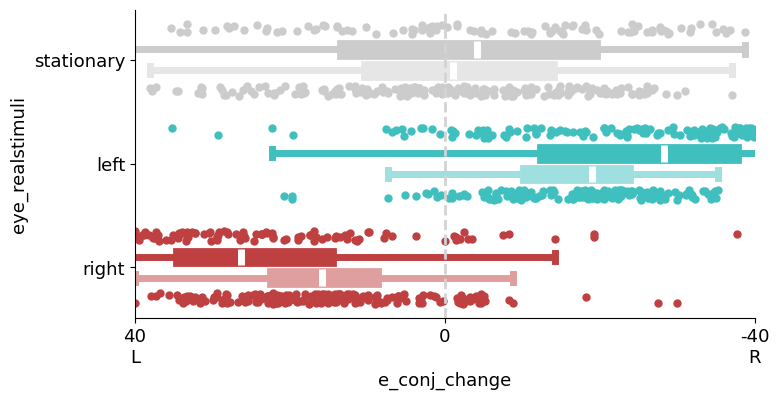

In [43]:
def plot_fish_saccade(all_df, stimorder, params, genotype):
    """Plot mean saccade for individual fish
    """
    fig, ax = plt.subplots(1, 1, figsize = (8, 4))
    bars = sns.boxplot(all_df, y = 'eye_realstimuli', x = params,  hue = 'Genotype', dodge = True, ax = ax, order= stimorder, hue_order = genotype, orient = 'h', linewidth=5, linecolor='white', zorder =0, width = 0.4, gap = 0.2, legend = False)

    #asign colors to the bar: less important
    count = all_df.groupby(['eye_realstimuli', 'Genotype']).count()
    count = list(count.reindex(stimorder, level='eye_realstimuli').iloc[:, 0])
    v = 0
    for i in range(len(count)):
        if count[i] > 0:  #box exist
            stim = stimorder[v % len(stimorder)]
            color = list(utils.stim_colors[stim])
            color = np.array(color)
            if i // (len(stimorder) ) != 0:
                color = 0.5 + 0.5 * np.array(color)
            bar = bars.patches[v]
            bar.set_edgecolor(color)
            bar.set_facecolor(color)
            bar.set_linewidth(2)
            for k in range(v * 6, (v + 1) * 6):
                if k != 4 + v * 6:
                    ax.lines[k].set_color(color)
            v += 1

    #plot scatter plot
    group_coord = [(-0.35, -0.25), (0.25, 0.35)]#[(-0.3, -0.28), (-0.12, -0.1), (0.1, 0.12), (0.28, 0.3)]#
    for i in range(0, len(stimorder)):
        for group_i, group in enumerate(genotype):
            x = stimorder[i]
            datatoplot = all_df[all_df.Genotype == group]
            y = list(datatoplot[datatoplot['eye_realstimuli'] == stimorder[i]][params])
            color = utils.stim_colors[x]
            ax.scatter(y = np.add([i] * len(y), np.random.uniform(group_coord[group_i][0], group_coord[group_i][1], len(y))), x=y,
                            color = color, alpha =1, s = 100, zorder = 1, marker = '.')

    #make axis prettier
    ax.axvline(0, linewidth = 2, color = 'lightgrey', linestyle = '--')
    ax.set_xlim([-40, 40])
    ax.spines[['top', 'right']].set_visible(False)

    ax.set_xlabel(params)

    ax.set_xticks([-40, 0, 40])
    ax.set_xticklabels(['40\nL', '0', '-40\nR'])

    plt.show()
    plt.close()
    return fig
fig = plot_fish_saccade(all_dfs, stimorder, 'e_conj_change', genotypes.keys())
plt.show()
plt.close()
#fig.savefig(r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260325\All_behavior\260331//individual_saccade_byfish.svg")

__TASK 1: IS THERE A DIFFERENCE IN THE FREQUENCY OF SACCADE?__

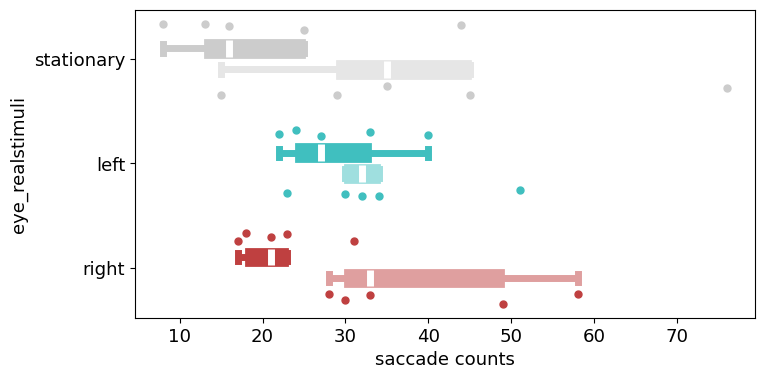

In [45]:
#count frequency
freq_df = (
    all_dfs
    .groupby(['fish_id', 'eye_realstimuli', 'Genotype'])
    .size()
    .reset_index(name='saccade_freq')
)

#plot
def plot_fish_saccade(all_df, stimorder, params, genotype):

    fig, ax = plt.subplots(1, 1, figsize = (8, 4))
    bars = sns.boxplot(freq_df, y = 'eye_realstimuli', x = params,  hue = 'Genotype', dodge = True, ax = ax, order= stimorder, hue_order = genotype, orient = 'h', linewidth=5, linecolor='white', zorder =0, width = 0.4, gap = 0.2, legend = False)

    #asign colors to the bar: less important
    count = all_df.groupby(['eye_realstimuli', 'Genotype']).count()
    count = list(count.reindex(stimorder, level='eye_realstimuli').iloc[:, 0])
    v = 0
    for i in range(len(count)):
        if count[i] > 0:  #box exist
            stim = stimorder[v % len(stimorder)]
            color = list(utils.stim_colors[stim])
            color = np.array(color)
            if i // (len(stimorder) ) != 0:
                color = 0.5 + 0.5 * np.array(color)
            bar = bars.patches[v]
            bar.set_edgecolor(color)
            bar.set_facecolor(color)
            bar.set_linewidth(2)
            for k in range(v * 6, (v + 1) * 6):
                if k != 4 + v * 6:
                    ax.lines[k].set_color(color)
            v += 1

    #plot scatter plot
    group_coord = [(-0.35, -0.25), (0.25, 0.35)]#[(-0.3, -0.28), (-0.12, -0.1), (0.1, 0.12), (0.28, 0.3)]#
    for i in range(0, len(stimorder)):
        for group_i, group in enumerate(genotype):
            x = stimorder[i]
            datatoplot = all_df[all_df.Genotype == group]
            y = list(datatoplot[datatoplot['eye_realstimuli'] == stimorder[i]][params])
            color = utils.stim_colors[x]
            ax.scatter(y = np.add([i] * len(y), np.random.uniform(group_coord[group_i][0], group_coord[group_i][1], len(y))), x=y,
                            color = color, alpha =1, s = 100, zorder = 1, marker = '.')

    ax.set_xlabel('saccade counts')
fig = plot_fish_saccade(freq_df, stimorder, 'saccade_freq', genotypes.keys())
plt.show()
plt.close()

__TASK 2: DURING STATIONARY PERIOD, DO FRMD7KO FISH EXPERIENCE "involuntary changes in the direction of their eye movements (periodic alternating nystagmus)"__

In [5]:
#clue: consider plot the eye traces from eye_df in both fish
#clue: if there's periodic change, the current saccade is more likely to be the same direction as the previous saccade...

In [36]:
#stationary df
df_stat = all_dfs[
    (all_dfs['eye_realstimuli'] == 'stationary') &
    (all_dfs['Genotype'] == 'frmd7KO')]

df_stat

,cont_tuples_eyeindex,cont_tuples_realtime_s,e0_change,e1_change,eye_stimuli,eye_realstimuli,eye_fromstart_s,e_conv_change,e_conj_change,fish_id,Genotype
383,"(506, 590)","(4.28753, 5.264916)",14.117682,12.922005,right,stationary,4.287530,-1.195677,27.039687,C:\Data\Imaging\260325_frmd7\fish17,frmd7KO
394,"(9347, 9430)","(107.103506, 108.057952)",-8.343719,-16.651232,dot_r,stationary,6.937443,-8.307513,-24.994951,C:\Data\Imaging\260325_frmd7\fish17,frmd7KO
395,"(10839, 10919)","(124.247646, 125.181149)",11.791571,8.168294,right,stationary,4.032213,-3.623277,19.959865,C:\Data\Imaging\260325_frmd7\fish17,frmd7KO
402,"(14762, 14846)","(169.277196, 170.243611)",14.324220,11.755183,left,stationary,9.015883,-2.569037,26.079403,C:\Data\Imaging\260325_frmd7\fish17,frmd7KO
420,"(29919, 29996)","(343.606881, 344.472562)",11.059154,-4.792224,dot_r,stationary,3.076772,-15.851378,6.266930,C:\Data\Imaging\260325_frmd7\fish17,frmd7KO
...,...,...,...,...,...,...,...,...,...,...,...
983,"(102934, 103072)","(1164.718983, 1166.250888)",16.492789,4.458324,dot_l,stationary,3.229360,-12.034465,20.951114,C:\Data\Imaging\260325_frmd7\fish14,frmd7KO
985,"(108442, 108523)","(1225.881378, 1226.780972)",-4.152007,-4.658541,pause,stationary,24.323936,-0.506533,-8.810548,C:\Data\Imaging\260325_frmd7\fish14,frmd7KO
986,"(114816, 114941)","(1296.662045, 1298.049334)",9.941162,-4.870130,pause,stationary,95.104603,-14.811292,5.071032,C:\Data\Imaging\260325_frmd7\fish14,frmd7KO
987,"(127247, 127382)","(1434.711774, 1436.210766)",4.325956,-5.996992,pause,stationary,233.154332,-10.322948,-1.671036,C:\Data\Imaging\260325_frmd7\fish14,frmd7KO
